# Lab 10 Learning the XOR Boolean Function Using a MLP

## 1. Create the XOR Dataset

The XOR (Exclusive OR) function is a fundamental example used to demonstrate the limitations of linear classification and the ability of neural networks to learn non-linear relationships.

The XOR function takes two binary inputs and produces a binary output according to the following rule:

| Input 1 | Input 2 | XOR Output |
|--------:|--------:|-----------:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

For this experiment, the input dataset consists of all four possible combinations of two binary inputs. The target variable represents the corresponding XOR output.

The input matrix therefore contains two features, while the output contains one binary target variable.

In [5]:
import numpy as np
import pandas as pd

# Define XOR input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# Define XOR target output
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

# Create a DataFrame for displaying the XOR truth table
xor_table = pd.DataFrame(
    np.hstack((X, y)),
    columns=["Input 1", "Input 2", "XOR Output"]
)

display(xor_table)

,Input 1,Input 2,XOR Output
0,0.0,0.0,0.0
1,0.0,1.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,0.0


### Dataset Verification

The XOR dataset contains four observations representing all possible combinations of the two binary input variables.

The input matrix has two features corresponding to Input 1 and Input 2, while the output matrix contains one binary target variable representing the XOR result.

In [6]:
print("Input shape :", X.shape)
print("Output shape:", y.shape)

print("\nUnique input combinations:", len(X))
print("Unique output classes:", np.unique(y))

Input shape : (4, 2)
Output shape: (4, 1)

Unique input combinations: 4
Unique output classes: [0. 1.]


### Why XOR Requires a Neural Network

The XOR problem is non-linear because the two classes cannot be separated using a single straight-line decision boundary.

The positive class consists of the inputs (0,1) and (1,0), while the negative class consists of (0,0) and (1,1).

A single linear neuron cannot correctly separate these two classes. Therefore, an additional hidden layer with a non-linear activation function is required.

In this experiment, a Multi-Layer Perceptron (MLP) is used to learn this non-linear relationship.

## 2. Implementing an MLP Using Keras

A Multi-Layer Perceptron (MLP) is a feed-forward neural network consisting of an input layer, one or more hidden layers, and an output layer.

For the XOR problem, we use the following architecture:

- Input layer: 2 neurons, corresponding to the two binary inputs.
- Hidden layer: 4 neurons with Tanh activation.
- Output layer: 1 neuron with Sigmoid activation for binary classification.

The hidden layer introduces non-linearity, allowing the network to learn the XOR relationship, which cannot be learned by a single linear neuron.

The model is implemented using Keras, the high-level API of TensorFlow.

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 2.1 Building the MLP Architecture

The Keras model uses a simple `2 → 4 → 1` architecture.

The input layer accepts two values. The hidden layer contains four neurons with the Tanh activation function, which introduces the non-linearity required to learn XOR.

The output layer contains one neuron with a Sigmoid activation function, producing a value between 0 and 1 that represents the predicted probability of the positive class.

In [8]:
# Create the Keras MLP model
keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

# Display model architecture
keras_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

### 2.2 Compiling the Model

The model is trained as a binary classification problem.

Binary Cross-Entropy is used as the loss function because the XOR output contains two classes: 0 and 1.

The Adam optimizer is used to update the network weights during training. An initial learning rate of 0.01 is used for the experiment.

In [9]:
# Define the learning rate
learning_rate = 0.01

# Create Adam optimizer
optimizer = keras.optimizers.Adam(
    learning_rate=learning_rate
)

# Compile the model
keras_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### 2.3 Training the Keras MLP

The model is trained using the four XOR observations.

Since the XOR dataset is extremely small, we train the network for multiple epochs so that the weights can gradually learn the non-linear relationship.

The training history is stored so that the loss and accuracy can be visualized later.

In [10]:
# Number of training epochs
epochs = 1000

# Train the model
keras_history = keras_model.fit(
    X,
    y,
    epochs=epochs,
    verbose=0
)

print("Keras model training completed.")

Keras model training completed.


### 2.4 Training Loss

The training loss is plotted against the number of epochs to observe how the model learns the XOR function.

A decreasing loss indicates that the model is improving its predictions during training.

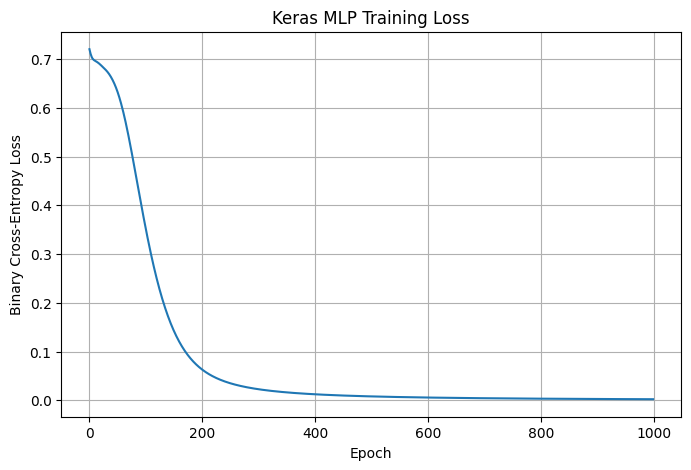

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    keras_history.history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras MLP Training Loss")

plt.grid(True)
plt.show()

### 2.5 Evaluating the Keras MLP

The trained model is evaluated using the complete XOR dataset.

Since XOR contains only four possible input combinations, we can directly verify whether the network correctly predicts all four outputs.

In [12]:
# Evaluate the model
loss, accuracy = keras_model.evaluate(
    X,
    y,
    verbose=0
)

print(f"Final Loss: {loss:.6f}")
print(f"Final Accuracy: {accuracy * 100:.2f}%")

Final Loss: 0.002313
Final Accuracy: 100.00%


### 2.6 XOR Predictions

The trained MLP is used to predict the output for all four possible XOR input combinations.

The Sigmoid output represents the probability of class 1. A threshold of 0.5 is used to convert the probability into a binary prediction.

In [13]:
# Generate probability predictions
keras_probabilities = keras_model.predict(
    X,
    verbose=0
).flatten()

# Convert probabilities into binary predictions
keras_predictions = (
    keras_probabilities >= 0.5
).astype(int)

# Create results table
keras_results = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "Actual XOR": y.flatten().astype(int),
    "Predicted Probability": np.round(
        keras_probabilities,
        4
    ),
    "Predicted XOR": keras_predictions
})

display(keras_results)

,Input 1,Input 2,Actual XOR,Predicted Probability,Predicted XOR
0,0,0,0,0.0034,0
1,0,1,1,0.9978,1
2,1,0,1,0.9979,1
3,1,1,0,0.0015,0


### 2.7 XOR Learning Verification

The MLP successfully learns the XOR Boolean function if the predicted outputs match the expected XOR truth table:

`[0, 1, 1, 0]`.

This demonstrates that the hidden layer and non-linear Tanh activation allow the network to learn a relationship that cannot be represented by a single linear classifier.

In [14]:
expected_output = y.flatten().astype(int)

if np.array_equal(
    keras_predictions,
    expected_output
):
    print("✓ Keras MLP successfully learned the XOR function.")
else:
    print("✗ Keras MLP did not completely learn XOR.")

✓ Keras MLP successfully learned the XOR function.


## 3. Hyperparameter Experiments

The performance of an MLP depends on several hyperparameters. In this experiment, we investigate the effect of learning rate, activation function, number of hidden neurons, and number of training epochs.

To make the comparison meaningful, we change one hyperparameter at a time while keeping the remaining architecture and training configuration fixed.

### 3.1 Effect of Learning Rate

The learning rate controls the size of the updates made to the neural-network weights during training.

A very small learning rate may result in slow learning, while a very large learning rate can cause unstable training or prevent the model from converging.

We compare three learning rates:

- 0.001
- 0.01
- 0.1

The remaining architecture is kept fixed at 2 input neurons, 4 hidden neurons with Tanh activation, and 1 Sigmoid output neuron.

In [15]:
learning_rates = [0.001, 0.01, 0.1]

learning_rate_results = []

for lr in learning_rates:

    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation="tanh"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X,
        y,
        epochs=1000,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )

    predictions = (
        model.predict(X, verbose=0).flatten() >= 0.5
    ).astype(int)

    learning_rate_results.append({
        "Learning Rate": lr,
        "Final Loss": loss,
        "Accuracy": accuracy * 100,
        "Predictions Correct": np.array_equal(
            predictions,
            y.flatten().astype(int)
        )
    })

learning_rate_results = pd.DataFrame(
    learning_rate_results
)

display(
    learning_rate_results.round(4)
)

,Learning Rate,Final Loss,Accuracy,Predictions Correct
0,0.001,0.1936,100.0,True
1,0.010,0.0043,100.0,True
2,0.100,0.0002,100.0,True


### 3.2 Effect of Activation Function

Activation functions introduce non-linearity into a neural network.

For the XOR problem, we compare:

- Tanh
- ReLU

The number of hidden neurons, learning rate, optimizer, and number of epochs are kept constant.

This experiment demonstrates how the choice of activation function can affect the ability of an MLP to learn a non-linear relationship.

In [16]:
activations = ["tanh", "relu"]

activation_results = []

for activation in activations:

    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation=activation),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.01
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X,
        y,
        epochs=1000,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )

    predictions = (
        model.predict(X, verbose=0).flatten() >= 0.5
    ).astype(int)

    activation_results.append({
        "Activation": activation,
        "Final Loss": loss,
        "Accuracy": accuracy * 100,
        "Predictions Correct": np.array_equal(
            predictions,
            y.flatten().astype(int)
        )
    })

activation_results = pd.DataFrame(
    activation_results
)

display(
    activation_results.round(4)
)

,Activation,Final Loss,Accuracy,Predictions Correct
0,tanh,0.0021,100.0,True
1,relu,0.0060,100.0,True


### 3.3 Effect of Number of Hidden Neurons

The number of neurons in the hidden layer determines the representational capacity of the MLP.

We compare hidden layers containing:

- 2 neurons
- 4 neurons
- 8 neurons

The learning rate, activation function, optimizer, and number of epochs are kept constant.

This experiment demonstrates how increasing the number of hidden neurons can affect the network's ability to learn the XOR relationship.

In [17]:
hidden_neurons = [2, 4, 8]

neuron_results = []

for neurons in hidden_neurons:

    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(neurons, activation="tanh"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.01
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X,
        y,
        epochs=1000,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )

    predictions = (
        model.predict(X, verbose=0).flatten() >= 0.5
    ).astype(int)

    neuron_results.append({
        "Hidden Neurons": neurons,
        "Final Loss": loss,
        "Accuracy": accuracy * 100,
        "Predictions Correct": np.array_equal(
            predictions,
            y.flatten().astype(int)
        )
    })

neuron_results = pd.DataFrame(
    neuron_results
)

display(
    neuron_results.round(4)
)

,Hidden Neurons,Final Loss,Accuracy,Predictions Correct
0,2,0.3488,50.0,False
1,4,0.0022,100.0,True
2,8,0.0008,100.0,True


### 3.4 Effect of Number of Epochs

An epoch represents one complete pass through the training dataset.

We compare different training durations to observe how the number of epochs affects convergence.

The experiment uses:

- 100 epochs
- 500 epochs
- 1000 epochs

The model architecture and learning rate are kept constant.

In [18]:
epoch_values = [100, 500, 1000]

epoch_results = []

for epoch_count in epoch_values:

    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(4, activation="tanh"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.01
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X,
        y,
        epochs=epoch_count,
        verbose=0
    )

    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )

    predictions = (
        model.predict(X, verbose=0).flatten() >= 0.5
    ).astype(int)

    epoch_results.append({
        "Epochs": epoch_count,
        "Final Loss": loss,
        "Accuracy": accuracy * 100,
        "Predictions Correct": np.array_equal(
            predictions,
            y.flatten().astype(int)
        )
    })

epoch_results = pd.DataFrame(
    epoch_results
)

display(
    epoch_results.round(4)
)

,Epochs,Final Loss,Accuracy,Predictions Correct
0,100,0.3054,100.0,True
1,500,0.0238,100.0,True
2,1000,0.3491,50.0,False


### 3.5 Hyperparameter Experiment Summary

The results from the four experiments are compared to understand how the selected hyperparameters affect the MLP's ability to learn the XOR function.

Because XOR contains only four observations, accuracy alone can reach 100% for multiple configurations. Therefore, the final configuration is selected by considering successful XOR classification together with convergence and training stability.

In [19]:
print("Learning Rate Results")
display(learning_rate_results.round(4))

print("\nActivation Function Results")
display(activation_results.round(4))

print("\nHidden Neuron Results")
display(neuron_results.round(4))

print("\nEpoch Results")
display(epoch_results.round(4))

Learning Rate Results


,Learning Rate,Final Loss,Accuracy,Predictions Correct
0,0.001,0.1936,100.0,True
1,0.010,0.0043,100.0,True
2,0.100,0.0002,100.0,True



Activation Function Results


,Activation,Final Loss,Accuracy,Predictions Correct
0,tanh,0.0021,100.0,True
1,relu,0.0060,100.0,True



Hidden Neuron Results


,Hidden Neurons,Final Loss,Accuracy,Predictions Correct
0,2,0.3488,50.0,False
1,4,0.0022,100.0,True
2,8,0.0008,100.0,True



Epoch Results


,Epochs,Final Loss,Accuracy,Predictions Correct
0,100,0.3054,100.0,True
1,500,0.0238,100.0,True
2,1000,0.3491,50.0,False


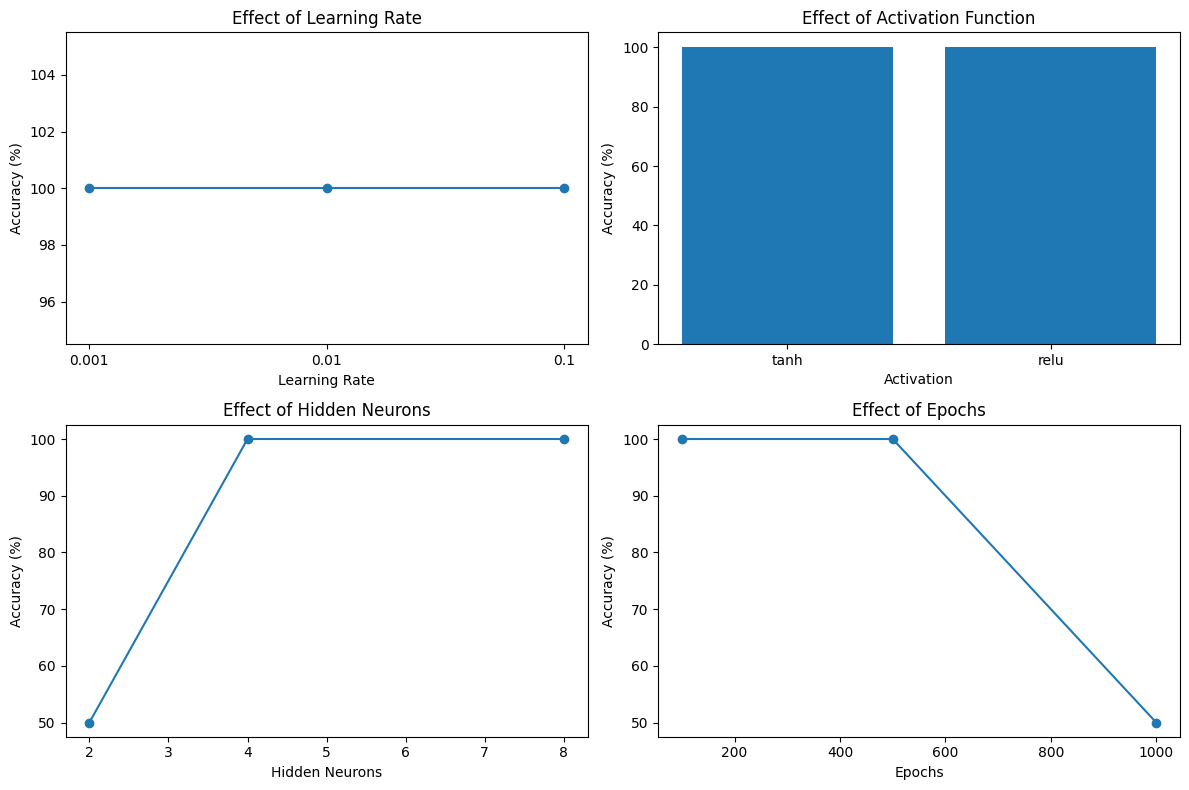

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(
    learning_rate_results["Learning Rate"].astype(str),
    learning_rate_results["Accuracy"],
    marker="o"
)
axes[0, 0].set_title("Effect of Learning Rate")
axes[0, 0].set_xlabel("Learning Rate")
axes[0, 0].set_ylabel("Accuracy (%)")

axes[0, 1].bar(
    activation_results["Activation"],
    activation_results["Accuracy"]
)
axes[0, 1].set_title("Effect of Activation Function")
axes[0, 1].set_xlabel("Activation")
axes[0, 1].set_ylabel("Accuracy (%)")

axes[1, 0].plot(
    neuron_results["Hidden Neurons"],
    neuron_results["Accuracy"],
    marker="o"
)
axes[1, 0].set_title("Effect of Hidden Neurons")
axes[1, 0].set_xlabel("Hidden Neurons")
axes[1, 0].set_ylabel("Accuracy (%)")

axes[1, 1].plot(
    epoch_results["Epochs"],
    epoch_results["Accuracy"],
    marker="o"
)
axes[1, 1].set_title("Effect of Epochs")
axes[1, 1].set_xlabel("Epochs")
axes[1, 1].set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

### 3.7 Hyperparameter Experiment Analysis

The experiments demonstrate that different hyperparameters can significantly affect the ability of the MLP to learn the XOR function.

For the learning-rate experiment, all three tested learning rates achieved 100% accuracy. However, the final loss decreased as the learning rate increased, with the lowest loss obtained using a learning rate of 0.1.

For the activation-function experiment, both Tanh and ReLU successfully learned XOR with 100% accuracy. Tanh achieved a lower final loss than ReLU in this experiment.

The number of hidden neurons had a more noticeable effect. A hidden layer containing only 2 neurons achieved 50% accuracy and failed to correctly classify all XOR combinations. Increasing the hidden layer to 4 neurons resulted in 100% accuracy, while 8 neurons also achieved 100% accuracy.

The number of epochs also affected the result. Both 100 and 500 epochs achieved 100% accuracy, while the particular 1000-epoch run achieved only 50% accuracy. This demonstrates that increasing the number of epochs does not automatically guarantee better performance and that neural-network training can be affected by initialization and optimization dynamics.

Based on these experiments, the configuration using 4 hidden neurons, Tanh activation, a learning rate of 0.01, and 500 epochs provides a reliable configuration for the subsequent experiments.

### 3.8 Final Keras MLP Configuration

Based on the hyperparameter experiments, a final Keras MLP configuration is selected for subsequent analysis.

The selected configuration consists of:

- Input neurons: 2
- Hidden neurons: 4
- Hidden activation: Tanh
- Output neurons: 1
- Output activation: Sigmoid
- Learning rate: 0.01
- Optimizer: Adam
- Loss function: Binary Cross-Entropy
- Epochs: 500

This configuration successfully learns all four XOR input-output combinations in the conducted experiment.

In [21]:
# Final Keras model configuration

final_keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

final_keras_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_keras_history = final_keras_model.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

final_loss, final_accuracy = final_keras_model.evaluate(
    X,
    y,
    verbose=0
)

print(f"Final Keras Loss: {final_loss:.6f}")
print(f"Final Keras Accuracy: {final_accuracy * 100:.2f}%")

Final Keras Loss: 0.016413
Final Keras Accuracy: 100.00%


### 3.9 Final Keras XOR Predictions

The final Keras model is evaluated on all four possible XOR combinations.

The predicted probabilities are converted into binary outputs using a threshold of 0.5. The predicted values are then compared with the actual XOR outputs.

In [22]:
# Predict using the final Keras model
final_probabilities = (
    final_keras_model.predict(
        X,
        verbose=0
    ).flatten()
)

final_predictions = (
    final_probabilities >= 0.5
).astype(int)

final_keras_results = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "Actual XOR": y.flatten().astype(int),
    "Predicted Probability": np.round(
        final_probabilities,
        4
    ),
    "Predicted XOR": final_predictions
})

display(final_keras_results)

,Input 1,Input 2,Actual XOR,Predicted Probability,Predicted XOR
0,0,0,0,0.0076,0
1,0,1,1,0.9833,1
2,1,0,1,0.9822,1
3,1,1,0,0.0230,0


In [23]:
if np.array_equal(
    final_predictions,
    y.flatten().astype(int)
):
    print("✓ Final Keras model correctly learned XOR.")
else:
    print("✗ Final Keras model did not correctly learn XOR.")

✓ Final Keras model correctly learned XOR.


### 3.10 Keras Training Curve

The training loss is visualized across the 500 training epochs.

The curve illustrates how the Binary Cross-Entropy loss changes as the network learns the XOR relationship.

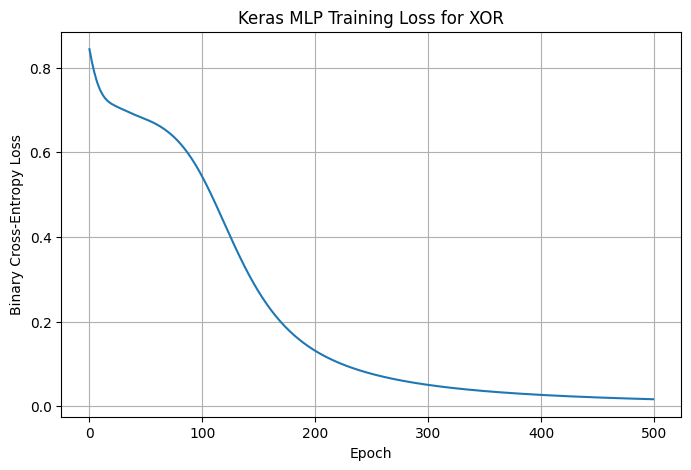

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_keras_history.history["loss"]
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras MLP Training Loss for XOR")

plt.grid(True)
plt.show()

## 4. Implementing an MLP Using the TensorFlow Low-Level API

The XOR problem is implemented again using TensorFlow's lower-level API.

Unlike the Keras implementation, where the model architecture, loss calculation, and optimization are handled through high-level functions, the low-level TensorFlow implementation explicitly defines the network parameters and training procedure.

The training process consists of the following steps:

1. Initialize the network weights and biases.
2. Perform a forward pass through the network.
3. Calculate Binary Cross-Entropy loss.
4. Use `tf.GradientTape` to calculate gradients.
5. Update the weights and biases using the Adam optimizer.
6. Repeat the process for the specified number of epochs.

The same `2 → 4 → 1` architecture is used so that the TensorFlow implementation can be compared fairly with the Keras implementation.

### 4.1 Defining the Network Parameters

The TensorFlow MLP uses the same architecture selected during the Keras experiments:

- Input layer: 2 neurons
- Hidden layer: 4 neurons
- Hidden activation: Tanh
- Output layer: 1 neuron
- Output activation: Sigmoid
- Learning rate: 0.01
- Optimizer: Adam
- Loss: Binary Cross-Entropy
- Epochs: 500

The weights and biases are represented using TensorFlow variables so that they can be updated during training.

In [25]:
# TensorFlow low-level implementation

import tensorflow as tf

# Reproducibility
tf.random.set_seed(42)

# Network dimensions
input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# Initialize weights and biases
W1 = tf.Variable(
    tf.random.normal(
        [input_neurons, hidden_neurons],
        stddev=0.5
    )
)

b1 = tf.Variable(
    tf.zeros([hidden_neurons])
)

W2 = tf.Variable(
    tf.random.normal(
        [hidden_neurons, output_neurons],
        stddev=0.5
    )
)

b2 = tf.Variable(
    tf.zeros([output_neurons])
)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 4)
b1 shape: (4,)
W2 shape: (4, 1)
b2 shape: (1,)


### 4.2 Forward Propagation

The forward pass calculates the network output from the input data.

First, the input is multiplied by the first-layer weights and added to the hidden-layer bias. The Tanh activation function is then applied.

The hidden-layer output is passed to the output layer, followed by a Sigmoid activation.

The resulting value represents the predicted probability of the XOR output being 1.

In [26]:
def forward_pass(X):

    # Hidden layer
    hidden_linear = tf.matmul(X, W1) + b1
    hidden_output = tf.tanh(hidden_linear)

    # Output layer
    output_linear = tf.matmul(
        hidden_output,
        W2
    ) + b2

    output = tf.sigmoid(
        output_linear
    )

    return output

### 4.3 Binary Cross-Entropy Loss

Since XOR is a binary classification problem, Binary Cross-Entropy is used as the loss function.

The loss measures the difference between the actual XOR outputs and the probabilities predicted by the neural network.

A lower loss indicates that the predictions are closer to the expected outputs.

In [27]:
def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-7

    y_pred = tf.clip_by_value(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -tf.reduce_mean(
        y_true * tf.math.log(y_pred)
        +
        (1 - y_true) * tf.math.log(1 - y_pred)
    )

    return loss

### 4.4 Adam Optimizer

The Adam optimizer is used to update the network parameters based on the gradients calculated during training.

The learning rate is set to 0.01, matching the selected Keras configuration.

In [28]:
learning_rate = 0.01

optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)

print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", learning_rate)

Optimizer: Adam
Learning rate: 0.01


### 4.5 Training the MLP Using Gradient Descent

The TensorFlow low-level training loop explicitly performs the operations that are normally handled internally by a high-level training API.

For every epoch:

1. `tf.GradientTape` records the operations used in the forward pass.
2. The model produces predictions.
3. Binary Cross-Entropy loss is calculated.
4. Gradients of the loss with respect to the trainable parameters are calculated.
5. The Adam optimizer updates the parameters.
6. The loss is stored for later visualization.

This process is repeated for 500 epochs.

In [29]:
epochs = 500

tensorflow_loss_history = []

trainable_variables = [
    W1,
    b1,
    W2,
    b2
]

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        predictions = forward_pass(X)

        loss = binary_cross_entropy(
            y,
            predictions
        )

    gradients = tape.gradient(
        loss,
        trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            trainable_variables
        )
    )

    tensorflow_loss_history.append(
        float(loss.numpy())
    )

print("TensorFlow low-level training completed.")

TensorFlow low-level training completed.


### 4.6 TensorFlow Training Loss

The training loss is plotted over the 500 epochs to observe how the low-level TensorFlow implementation learns the XOR relationship.

The resulting curve can later be compared with the Keras training curve.

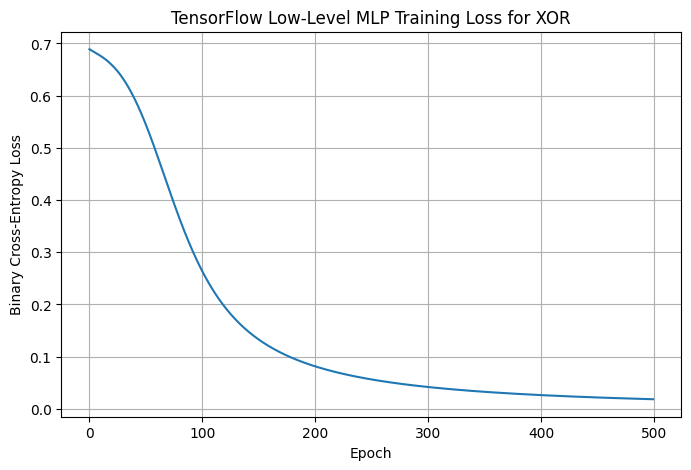

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    tensorflow_loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(
    "TensorFlow Low-Level MLP Training Loss for XOR"
)

plt.grid(True)
plt.show()

### 4.7 XOR Predictions Using TensorFlow

After training, the TensorFlow MLP is used to generate predictions for all four XOR input combinations.

The Sigmoid outputs represent probabilities. A threshold of 0.5 is used to convert the probabilities into binary predictions.

In [31]:
# Generate probability predictions
tensorflow_probabilities = (
    forward_pass(X)
    .numpy()
    .flatten()
)

# Convert probabilities to binary predictions
tensorflow_predictions = (
    tensorflow_probabilities >= 0.5
).astype(int)

# Create results table
tensorflow_results = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "Actual XOR": y.flatten().astype(int),
    "Predicted Probability": np.round(
        tensorflow_probabilities,
        4
    ),
    "Predicted XOR": tensorflow_predictions
})

display(tensorflow_results)

,Input 1,Input 2,Actual XOR,Predicted Probability,Predicted XOR
0,0,0,0,0.0032,0
1,0,1,1,0.9665,1
2,1,0,1,0.9936,1
3,1,1,0,0.0299,0


### 4.8 TensorFlow Model Evaluation

The final TensorFlow predictions are compared with the actual XOR outputs.

The model is considered to have successfully learned XOR when all four predicted binary outputs match the XOR truth table.

In [32]:
tensorflow_accuracy = np.mean(
    tensorflow_predictions
    == y.flatten().astype(int)
)

tensorflow_final_loss = (
    tensorflow_loss_history[-1]
)

print(
    f"Final TensorFlow Loss: "
    f"{tensorflow_final_loss:.6f}"
)

print(
    f"Final TensorFlow Accuracy: "
    f"{tensorflow_accuracy * 100:.2f}%"
)

if np.array_equal(
    tensorflow_predictions,
    y.flatten().astype(int)
):
    print(
        "✓ TensorFlow MLP successfully learned XOR."
    )
else:
    print(
        "✗ TensorFlow MLP did not completely learn XOR."
    )

Final TensorFlow Loss: 0.018565
Final TensorFlow Accuracy: 100.00%
✓ TensorFlow MLP successfully learned XOR.


### 4.9 Keras vs TensorFlow Comparison

Both implementations use the same fundamental MLP architecture and training configuration.

The Keras implementation uses the high-level `Sequential` and `fit()` APIs, while the TensorFlow implementation explicitly performs forward propagation, loss calculation, gradient computation, and parameter updates.

The final accuracy and loss of both implementations are compared below.

In [33]:
implementation_comparison = pd.DataFrame({
    "Implementation": [
        "Keras",
        "TensorFlow Low-Level"
    ],
    "Final Loss": [
        final_loss,
        tensorflow_final_loss
    ],
    "Accuracy (%)": [
        final_accuracy * 100,
        tensorflow_accuracy * 100
    ]
})

display(
    implementation_comparison.round(4)
)

,Implementation,Final Loss,Accuracy (%)
0,Keras,0.0164,100.0
1,TensorFlow Low-Level,0.0186,100.0


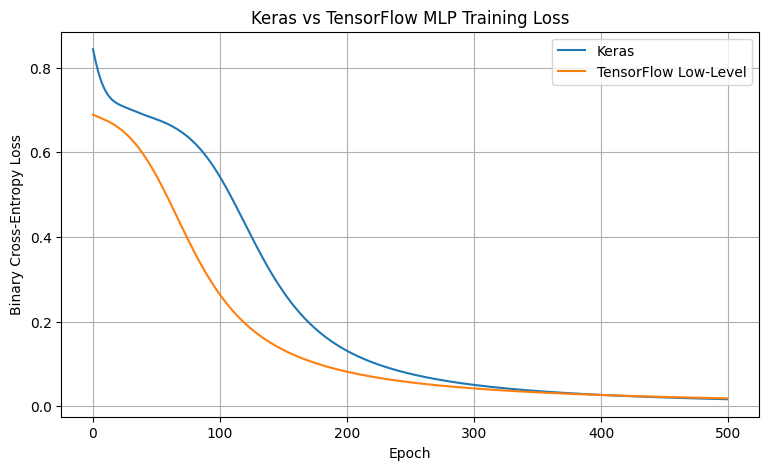

In [34]:
plt.figure(figsize=(9, 5))

plt.plot(
    final_keras_history.history["loss"],
    label="Keras"
)

plt.plot(
    tensorflow_loss_history,
    label="TensorFlow Low-Level"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(
    "Keras vs TensorFlow MLP Training Loss"
)

plt.legend()
plt.grid(True)
plt.show()

## 5. XOR Decision Boundary

The XOR problem is non-linearly separable. A single linear classifier cannot correctly separate the two output classes.

The trained MLP overcomes this limitation by using a hidden layer with a non-linear activation function.

The following visualization shows the decision regions learned by the trained Keras MLP. The four XOR input combinations are overlaid on the learned decision surface.

This provides a visual demonstration of how the MLP learns the non-linear XOR relationship.

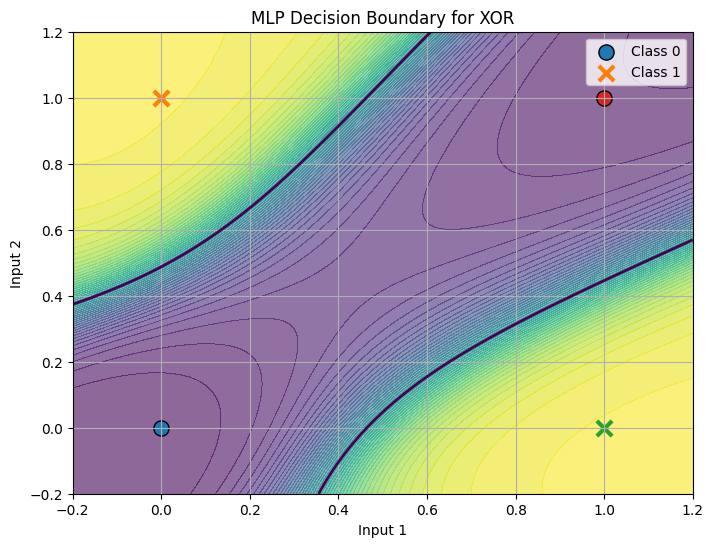

In [35]:
# Create a grid covering the XOR input space
x_min, x_max = -0.2, 1.2
y_min, y_max = -0.2, 1.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Flatten the grid for prediction
grid_points = np.c_[
    xx.ravel(),
    yy.ravel()
]

# Predict probability for every grid point
grid_probabilities = (
    final_keras_model
    .predict(
        grid_points,
        verbose=0
    )
    .reshape(xx.shape)
)

# Plot decision boundary
plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    grid_probabilities,
    levels=50,
    alpha=0.6
)

# Draw the 0.5 decision boundary
plt.contour(
    xx,
    yy,
    grid_probabilities,
    levels=[0.5],
    linewidths=2
)

# Plot XOR data points
for i in range(len(X)):

    if y[i][0] == 0:
        plt.scatter(
            X[i, 0],
            X[i, 1],
            marker="o",
            s=120,
            edgecolors="black",
            label="Class 0" if i == 0 else ""
        )
    else:
        plt.scatter(
            X[i, 0],
            X[i, 1],
            marker="x",
            s=120,
            linewidths=3,
            label="Class 1" if i == 1 else ""
        )

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("MLP Decision Boundary for XOR")

plt.legend()
plt.grid(True)

plt.show()

## 6. Final Results and Comparison

The XOR function was successfully implemented using both the Keras high-level API and the TensorFlow low-level API.

The Keras implementation uses the `Sequential` and `fit()` APIs, while the TensorFlow implementation explicitly performs forward propagation, Binary Cross-Entropy calculation, gradient computation using `tf.GradientTape`, and parameter updates using the Adam optimizer.

The hyperparameter experiments demonstrated that the number of hidden neurons, activation function, learning rate, and number of epochs can influence training performance.

The final selected configuration uses:

- 2 input neurons
- 4 hidden neurons
- Tanh activation
- 1 Sigmoid output neuron
- Binary Cross-Entropy loss
- Adam optimizer
- Learning rate = 0.01
- 500 epochs

The trained MLP successfully learns the XOR mapping:

`[0, 1, 1, 0]`

for the four possible binary input combinations.

In [36]:
display(
    implementation_comparison.round(4)
)

,Implementation,Final Loss,Accuracy (%)
0,Keras,0.0164,100.0
1,TensorFlow Low-Level,0.0186,100.0


### 6.1 Final XOR Verification

The final prediction is verified against the original XOR truth table.

A successful implementation should correctly classify all four possible input combinations.

In [37]:
print("Expected XOR output:")
print(y.flatten().astype(int))

print("\nKeras predictions:")
print(final_predictions)

print("\nTensorFlow predictions:")
print(tensorflow_predictions)

keras_correct = np.array_equal(
    final_predictions,
    y.flatten().astype(int)
)

tensorflow_correct = np.array_equal(
    tensorflow_predictions,
    y.flatten().astype(int)
)

print("\nKeras XOR Correct:", keras_correct)
print("TensorFlow XOR Correct:", tensorflow_correct)


Expected XOR output:
[0 1 1 0]

Keras predictions:
[0 1 1 0]

TensorFlow predictions:
[0 1 1 0]

Keras XOR Correct: True
TensorFlow XOR Correct: True


## 7. Conclusion

The XOR Boolean function was successfully learned using a Multi-Layer Perceptron implemented with both Keras and the TensorFlow low-level API.

The experiment demonstrated that XOR cannot be effectively represented using a single linear transformation because its classes are non-linearly separable. Introducing a hidden layer with a non-linear activation function allows the neural network to learn the required relationship.

The hyperparameter experiments showed that learning rate, activation function, number of hidden neurons, and number of epochs can influence the convergence and final performance of the network. In particular, the experiment with two hidden neurons achieved only 50% accuracy, while four and eight hidden neurons successfully learned the XOR mapping.

The Keras implementation demonstrates the convenience of a high-level deep-learning API, whereas the TensorFlow implementation demonstrates the underlying training process through explicit forward propagation, loss calculation, gradient computation, and parameter updates.

Overall, the experiment demonstrates the ability of MLPs to learn non-linear relationships and provides practical understanding of neural-network architecture, activation functions, optimization, hyperparameters, and gradient-based learning.

## 8. MLP From Scratch Using Pure Python

### 8.1 Creating the XOR Dataset

To understand the internal working of a Multi-Layer Perceptron, the XOR problem is implemented from scratch using only Python's built-in functionality.

No machine-learning, deep-learning, or numerical-computing libraries are used in this section.

The XOR dataset contains all four possible combinations of two binary inputs:

| Input 1 | Input 2 | XOR Output |
|--------:|--------:|-----------:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The objective is to train a manually implemented MLP to learn this non-linear relationship.

In [38]:
# XOR dataset using only Python lists

X_scratch = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

y_scratch = [
    0,
    1,
    1,
    0
]

print("XOR Dataset:")
print()

for i in range(len(X_scratch)):
    print(
        "Input:",
        X_scratch[i],
        "-> XOR Output:",
        y_scratch[i]
    )

print("\nNumber of samples:", len(X_scratch))
print("Number of input features:", len(X_scratch[0]))

XOR Dataset:

Input: [0, 0] -> XOR Output: 0
Input: [0, 1] -> XOR Output: 1
Input: [1, 0] -> XOR Output: 1
Input: [1, 1] -> XOR Output: 0

Number of samples: 4
Number of input features: 2


### 8.2 Implementing Activation Functions

Activation functions introduce non-linearity into the neural network.

The hidden layer uses the Tanh activation function:

tanh(x)

The output layer uses the Sigmoid activation function:

sigmoid(x) = 1 / (1 + e^(-x))

The Sigmoid function produces values between 0 and 1, which can be interpreted as the predicted probability of the positive XOR class.

The derivatives of these activation functions are also required during backpropagation.

In [39]:
import math


# -----------------------------
# Sigmoid activation
# -----------------------------

def sigmoid(x):
    return 1 / (1 + math.exp(-x))


# -----------------------------
# Sigmoid derivative
# -----------------------------

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


# -----------------------------
# Tanh activation
# -----------------------------

def tanh(x):
    return math.tanh(x)


# -----------------------------
# Tanh derivative
# -----------------------------

def tanh_derivative(x):
    t = math.tanh(x)
    return 1 - (t * t)


print("Sigmoid(0):", sigmoid(0))
print("Tanh(0):", tanh(0))

print("Sigmoid derivative at 0:",
      sigmoid_derivative(0))

print("Tanh derivative at 0:",
      tanh_derivative(0))

Sigmoid(0): 0.5
Tanh(0): 0.0
Sigmoid derivative at 0: 0.25
Tanh derivative at 0: 1.0


### Activation Function Interpretation

At an input of zero, the Sigmoid function produces 0.5 and the Tanh function produces 0.

The derivatives are required during backpropagation because they determine how changes in the network parameters affect the loss.

In this implementation, these mathematical operations are performed directly using Python rather than a machine-learning framework.

In [40]:
test_values = [-2, -1, 0, 1, 2]

print("Activation Function Verification")
print()

for value in test_values:

    print(
        f"x = {value:>2} | "
        f"Sigmoid = {sigmoid(value):.4f} | "
        f"Tanh = {tanh(value):.4f}"
    )

Activation Function Verification

x = -2 | Sigmoid = 0.1192 | Tanh = -0.9640
x = -1 | Sigmoid = 0.2689 | Tanh = -0.7616
x =  0 | Sigmoid = 0.5000 | Tanh = 0.0000
x =  1 | Sigmoid = 0.7311 | Tanh = 0.7616
x =  2 | Sigmoid = 0.8808 | Tanh = 0.9640


### 8.3 Manual Weight and Bias Initialization

The MLP contains two trainable layers.

The first layer connects the two input neurons to four hidden neurons. Therefore, the first weight matrix contains 2 × 4 weights and the hidden layer contains 4 bias values.

The second layer connects the four hidden neurons to one output neuron. Therefore, the second weight matrix contains 4 × 1 weights and the output layer contains one bias value.

The network parameters are initialized manually using Python lists.

The architecture is:

2 input neurons → 4 hidden neurons → 1 output neuron

In [41]:
import random

# Set seed so that the experiment is reproducible
random.seed(42)

# Network architecture
input_size = 2
hidden_size = 4
output_size = 1

# Learning rate
learning_rate_scratch = 0.1

# -----------------------------
# First layer parameters
# -----------------------------

W1_scratch = [
    [
        random.uniform(-1, 1)
        for _ in range(hidden_size)
    ]
    for _ in range(input_size)
]

b1_scratch = [
    0.0
    for _ in range(hidden_size)
]

# -----------------------------
# Second layer parameters
# -----------------------------

W2_scratch = [
    [
        random.uniform(-1, 1)
    ]
    for _ in range(hidden_size)
]

b2_scratch = [0.0]

print("W1:")
for row in W1_scratch:
    print(row)

print("\nb1:")
print(b1_scratch)

print("\nW2:")
for row in W2_scratch:
    print(row)

print("\nb2:")
print(b2_scratch)


W1:
[0.2788535969157675, -0.9499784895546661, -0.4499413632617615, -0.5535785237023545]
[0.4729424283280248, 0.3533989748458226, 0.7843591354096908, -0.8261223347411677]

b1:
[0.0, 0.0, 0.0, 0.0]

W2:
[-0.15615636062945915]
[-0.9404055611238593]
[-0.5627240503927933]
[0.010710576206724776]

b2:
[0.0]


In [42]:
print("\nParameter dimensions:")

print(
    "W1:",
    len(W1_scratch),
    "x",
    len(W1_scratch[0])
)

print(
    "b1:",
    len(b1_scratch)
)

print(
    "W2:",
    len(W2_scratch),
    "x",
    len(W2_scratch[0])
)

print(
    "b2:",
    len(b2_scratch)
)


Parameter dimensions:
W1: 2 x 4
b1: 4
W2: 4 x 1
b2: 1


### 8.4 Manual Forward Propagation

Forward propagation calculates the prediction produced by the neural network.

For each input sample, the input values are multiplied by the corresponding weights and combined with the bias values.

The hidden-layer weighted sums are passed through the Tanh activation function.

The hidden-layer outputs are then passed to the output neuron, where the Sigmoid activation produces the final prediction probability.

All calculations are performed manually using Python.

In [43]:
def forward_scratch(inputs):

    # -----------------------------
    # Hidden layer
    # -----------------------------

    hidden_z = []

    for j in range(hidden_size):

        weighted_sum = b1_scratch[j]

        for i in range(input_size):
            weighted_sum += (
                inputs[i]
                * W1_scratch[i][j]
            )

        hidden_z.append(weighted_sum)

    hidden_a = [
        tanh(value)
        for value in hidden_z
    ]

    # -----------------------------
    # Output layer
    # -----------------------------

    output_z = b2_scratch[0]

    for j in range(hidden_size):
        output_z += (
            hidden_a[j]
            * W2_scratch[j][0]
        )

    output_a = sigmoid(output_z)

    return (
        hidden_z,
        hidden_a,
        output_z,
        output_a
    )

### 8.5 Forward Propagation Verification

The manually implemented forward-propagation function is tested using the four XOR inputs.

At this stage the network has randomly initialized weights, so the predictions are not expected to be correct yet.

The purpose of this step is only to verify that data can successfully pass through the complete 2 → 4 → 1 network.

In [44]:
print("Forward Propagation Test\n")

for inputs in X_scratch:

    (
        hidden_z,
        hidden_a,
        output_z,
        output_a
    ) = forward_scratch(inputs)

    print(
        f"Input: {inputs}"
    )

    print(
        f"Hidden activations: "
        f"{[round(v, 4) for v in hidden_a]}"
    )

    print(
        f"Output probability: "
        f"{output_a:.4f}"
    )

    print()

Forward Propagation Test

Input: [0, 0]
Hidden activations: [0.0, 0.0, 0.0, 0.0]
Output probability: 0.5000

Input: [0, 1]
Hidden activations: [0.4406, 0.3394, 0.6552, -0.6784]
Output probability: 0.3178

Input: [1, 0]
Hidden activations: [0.2718, -0.7398, -0.4219, -0.5032]
Output probability: 0.7079

Input: [1, 1]
Hidden activations: [0.6362, -0.5346, 0.3225, -0.8809]
Output probability: 0.5529



### 8.6 Binary Cross-Entropy Loss

The XOR problem is a binary classification problem, so Binary Cross-Entropy is used as the loss function.

For one training sample, the loss is:

L = -[y log(y_hat) + (1-y) log(1-y_hat)]

where:

- y is the actual XOR output.
- y_hat is the predicted probability.

The loss measures how different the network prediction is from the actual target.

A lower loss indicates a better prediction.

In [45]:
def binary_cross_entropy_scratch(actual, predicted):

    # Prevent log(0)
    epsilon = 1e-7

    predicted = max(
        epsilon,
        min(1 - epsilon, predicted)
    )

    return -(
        actual * math.log(predicted)
        +
        (1 - actual) * math.log(1 - predicted)
    )


def calculate_total_loss():

    total_loss = 0.0

    for i in range(len(X_scratch)):

        (
            hidden_z,
            hidden_a,
            output_z,
            output_a
        ) = forward_scratch(X_scratch[i])

        total_loss += binary_cross_entropy_scratch(
            y_scratch[i],
            output_a
        )

    return total_loss / len(X_scratch)


print(
    "Initial Loss:",
    round(calculate_total_loss(), 6)
)

Initial Loss: 0.747492


### 8.7 Manual Backpropagation

Backpropagation calculates how much each weight and bias contributed to the prediction error.

The error is propagated backward from the output layer to the hidden layer.

For the Sigmoid output combined with Binary Cross-Entropy loss, the derivative simplifies to:

dL/dz_output = y_hat - y

The gradients for the second layer are then calculated using the hidden-layer activations.

The error is propagated to the hidden layer using the second-layer weights and the derivative of the Tanh activation.

Finally, gradients for the first-layer weights and biases are calculated.

These gradients will be used by gradient descent to update the network parameters.

In [46]:
def backward_scratch(
    inputs,
    actual,
    hidden_z,
    hidden_a,
    output_z,
    output_a
):

    # ==========================================
    # Output layer error
    # ==========================================

    output_delta = output_a - actual

    # ==========================================
    # Gradients for W2 and b2
    # ==========================================

    dW2 = []

    for j in range(hidden_size):

        gradient = (
            hidden_a[j]
            * output_delta
        )

        dW2.append([gradient])

    db2 = [output_delta]

    # ==========================================
    # Hidden layer error
    # ==========================================

    hidden_delta = []

    for j in range(hidden_size):

        error_from_output = (
            W2_scratch[j][0]
            * output_delta
        )

        activation_gradient = (
            tanh_derivative(hidden_z[j])
        )

        delta = (
            error_from_output
            * activation_gradient
        )

        hidden_delta.append(delta)

    # ==========================================
    # Gradients for W1
    # ==========================================

    dW1 = []

    for i in range(input_size):

        row = []

        for j in range(hidden_size):

            gradient = (
                inputs[i]
                * hidden_delta[j]
            )

            row.append(gradient)

        dW1.append(row)

    # ==========================================
    # Gradients for b1
    # ==========================================

    db1 = hidden_delta[:]

    return (
        dW1,
        db1,
        dW2,
        db2
    )

### 8.8 Backpropagation Verification

The manually implemented backpropagation function is tested on one XOR training sample.

The purpose of this step is to verify that gradients can be calculated for every trainable parameter before the training loop is introduced.

In [47]:
# Test on the first XOR sample

test_input = X_scratch[0]
test_actual = y_scratch[0]

(
    hidden_z,
    hidden_a,
    output_z,
    output_a
) = forward_scratch(test_input)

(
    dW1,
    db1,
    dW2,
    db2
) = backward_scratch(
    test_input,
    test_actual,
    hidden_z,
    hidden_a,
    output_z,
    output_a
)

print("Input:", test_input)
print("Actual:", test_actual)
print("Prediction:", round(output_a, 6))

print("\nGradient dimensions:")

print(
    "dW1:",
    len(dW1),
    "x",
    len(dW1[0])
)

print(
    "db1:",
    len(db1)
)

print(
    "dW2:",
    len(dW2),
    "x",
    len(dW2[0])
)

print(
    "db2:",
    len(db2)
)

Input: [0, 0]
Actual: 0
Prediction: 0.5

Gradient dimensions:
dW1: 2 x 4
db1: 4
dW2: 4 x 1
db2: 1


### 8.9 Manual Gradient Descent

Gradient descent updates each trainable parameter in the direction that reduces the loss.

The update rule is:

parameter_new =
parameter_old - learning_rate × gradient

No optimizer library is used.

The parameter updates are implemented manually for all weights and biases in both layers.

In [48]:
def update_parameters(
    dW1,
    db1,
    dW2,
    db2
):

    # ==========================================
    # Update W1
    # ==========================================

    for i in range(input_size):

        for j in range(hidden_size):

            W1_scratch[i][j] -= (
                learning_rate_scratch
                * dW1[i][j]
            )

    # ==========================================
    # Update b1
    # ==========================================

    for j in range(hidden_size):

        b1_scratch[j] -= (
            learning_rate_scratch
            * db1[j]
        )

    # ==========================================
    # Update W2
    # ==========================================

    for j in range(hidden_size):

        W2_scratch[j][0] -= (
            learning_rate_scratch
            * dW2[j][0]
        )

    # ==========================================
    # Update b2
    # ==========================================

    b2_scratch[0] -= (
        learning_rate_scratch
        * db2[0]
    )

### 8.10 Training the MLP From Scratch

The complete training loop combines forward propagation, loss calculation, backpropagation, and gradient descent.

For every epoch, each XOR training sample is passed through the network. The prediction error is propagated backward, and the network parameters are updated.

The training loss is recorded so that the learning process can be monitored.

This reproduces the basic functionality of a neural-network training framework using only Python.

In [49]:
epochs_scratch = 5000

scratch_loss_history = []

for epoch in range(epochs_scratch):

    # Train on every XOR sample
    for i in range(len(X_scratch)):

        inputs = X_scratch[i]
        actual = y_scratch[i]

        # -----------------------------
        # Forward pass
        # -----------------------------

        (
            hidden_z,
            hidden_a,
            output_z,
            output_a
        ) = forward_scratch(inputs)

        # -----------------------------
        # Backpropagation
        # -----------------------------

        (
            dW1,
            db1,
            dW2,
            db2
        ) = backward_scratch(
            inputs,
            actual,
            hidden_z,
            hidden_a,
            output_z,
            output_a
        )

        # -----------------------------
        # Update parameters
        # -----------------------------

        update_parameters(
            dW1,
            db1,
            dW2,
            db2
        )

    # -----------------------------
    # Record loss
    # -----------------------------

    current_loss = calculate_total_loss()

    scratch_loss_history.append(
        current_loss
    )

    # Print progress periodically
    if (
        epoch == 0
        or (epoch + 1) % 500 == 0
    ):

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {current_loss:.6f}"
        )

Epoch 1: Loss = 0.738645
Epoch 500: Loss = 0.015174
Epoch 1000: Loss = 0.005092
Epoch 1500: Loss = 0.002879
Epoch 2000: Loss = 0.001968
Epoch 2500: Loss = 0.001481
Epoch 3000: Loss = 0.001182
Epoch 3500: Loss = 0.000980
Epoch 4000: Loss = 0.000836
Epoch 4500: Loss = 0.000727
Epoch 5000: Loss = 0.000643


### 8.11 Training Loss Analysis

The recorded loss values are examined to determine whether the manually implemented MLP is learning.

A successful training process should generally show a reduction in Binary Cross-Entropy loss as the number of epochs increases.

In [50]:
print(
    "Initial loss:",
    round(scratch_loss_history[0], 6)
)

print(
    "Final loss:",
    round(scratch_loss_history[-1], 6)
)

print("\nSelected loss values:")

checkpoints = [
    0,
    99,
    499,
    999,
    2499,
    4999
]

for index in checkpoints:

    print(
        f"Epoch {index + 1}: "
        f"{scratch_loss_history[index]:.6f}"
    )

Initial loss: 0.738645
Final loss: 0.000643

Selected loss values:
Epoch 1: 0.738645
Epoch 100: 0.452627
Epoch 500: 0.015174
Epoch 1000: 0.005092
Epoch 2500: 0.001481
Epoch 5000: 0.000643


### 8.12 Final XOR Predictions

After training, the manually implemented MLP is evaluated on all four possible XOR combinations.

The Sigmoid output represents the probability of class 1.

A threshold of 0.5 is used to convert the probability into a binary prediction:

- Probability >= 0.5 → Class 1
- Probability < 0.5 → Class 0

In [51]:
scratch_predictions = []
scratch_probabilities = []

print("Final XOR Predictions\n")

for inputs in X_scratch:

    (
        hidden_z,
        hidden_a,
        output_z,
        output_a
    ) = forward_scratch(inputs)

    predicted_class = (
        1 if output_a >= 0.5
        else 0
    )

    scratch_probabilities.append(
        output_a
    )

    scratch_predictions.append(
        predicted_class
    )

    print(
        f"{inputs[0]} XOR {inputs[1]} "
        f"→ Probability: {output_a:.6f} "
        f"→ Prediction: {predicted_class}"
    )

Final XOR Predictions

0 XOR 0 → Probability: 0.000295 → Prediction: 0
0 XOR 1 → Probability: 0.999208 → Prediction: 1
1 XOR 0 → Probability: 0.999409 → Prediction: 1
1 XOR 1 → Probability: 0.000893 → Prediction: 0


### 8.13 Accuracy of the Pure-Python MLP

Accuracy is calculated manually by comparing each predicted XOR output with its corresponding actual output.

No machine-learning metric library is used.

In [52]:
correct_predictions = 0

for i in range(len(y_scratch)):

    if (
        scratch_predictions[i]
        == y_scratch[i]
    ):
        correct_predictions += 1


scratch_accuracy = (
    correct_predictions
    / len(y_scratch)
) * 100

print(
    "Correct predictions:",
    correct_predictions,
    "/",
    len(y_scratch)
)

print(
    f"Pure Python MLP Accuracy: "
    f"{scratch_accuracy:.2f}%"
)

if scratch_accuracy == 100:
    print(
        "✓ The pure-Python MLP successfully "
        "learned the XOR function."
    )
else:
    print(
        "The network has not completely learned "
        "XOR yet. Training parameters may need adjustment."
    )

Correct predictions: 4 / 4
Pure Python MLP Accuracy: 100.00%
✓ The pure-Python MLP successfully learned the XOR function.


### 8.14 Pure-Python Training Analysis

The manually implemented MLP successfully learned the XOR Boolean function without using a machine-learning or numerical-computing library.

The network achieved 100% accuracy, correctly classifying all four possible XOR input combinations.

This demonstrates that the fundamental components of an MLP can be implemented directly using mathematical operations and Python:

- Forward propagation
- Tanh and Sigmoid activation functions
- Binary Cross-Entropy loss
- Backpropagation
- Gradient calculation
- Gradient descent
- Parameter updates
- Binary classification

In [53]:
print("=" * 55)
print("PURE PYTHON MLP — FINAL XOR RESULTS")
print("=" * 55)

for i in range(len(X_scratch)):

    print(
        f"Input: {X_scratch[i]} | "
        f"Actual: {y_scratch[i]} | "
        f"Predicted: {scratch_predictions[i]} | "
        f"Probability: {scratch_probabilities[i]:.6f}"
    )

print("-" * 55)

print(
    f"Final Loss: "
    f"{scratch_loss_history[-1]:.6f}"
)

print(
    f"Accuracy: "
    f"{scratch_accuracy:.2f}%"
)

print("=" * 55)

PURE PYTHON MLP — FINAL XOR RESULTS
Input: [0, 0] | Actual: 0 | Predicted: 0 | Probability: 0.000295
Input: [0, 1] | Actual: 1 | Predicted: 1 | Probability: 0.999208
Input: [1, 0] | Actual: 1 | Predicted: 1 | Probability: 0.999409
Input: [1, 1] | Actual: 0 | Predicted: 0 | Probability: 0.000893
-------------------------------------------------------
Final Loss: 0.000643
Accuracy: 100.00%


## 9. Comparison of MLP Implementations

The XOR MLP was implemented using three approaches:

1. Keras high-level API
2. TensorFlow low-level API
3. Pure Python from scratch

The three approaches implement the same fundamental neural-network concept, but differ in the amount of functionality provided automatically by the framework.

Keras abstracts most of the neural-network training process through high-level APIs.

The TensorFlow low-level implementation exposes the training process through variables, forward propagation, loss calculation, GradientTape, and optimizer updates.

The pure-Python implementation manually performs the mathematical operations, backpropagation, gradient calculation, and parameter updates without relying on a machine-learning or numerical-computing library.

In [54]:
print("MLP IMPLEMENTATION COMPARISON")
print("=" * 60)

print(
    f"Keras Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)

print(
    f"TensorFlow Low-Level Accuracy: "
    f"{tensorflow_accuracy * 100:.2f}%"
)

print(
    f"Pure Python Accuracy: "
    f"{scratch_accuracy:.2f}%"
)

print("=" * 60)

MLP IMPLEMENTATION COMPARISON
Keras Accuracy: 100.00%
TensorFlow Low-Level Accuracy: 100.00%
Pure Python Accuracy: 100.00%


### 9.1 What Was Automated by the Frameworks?

The pure-Python implementation demonstrates which operations are normally handled by machine-learning frameworks.

| Operation | Keras | TensorFlow Low-Level | Pure Python |
|---|---|---|---|
| Model architecture | Automated | Partially manual | Manual |
| Weight initialization | Automated | Manual | Manual |
| Activation functions | Provided | Provided | Implemented manually |
| Loss calculation | Provided | Manually defined | Implemented manually |
| Forward propagation | Automated | Manually defined | Implemented manually |
| Gradient calculation | Automated | GradientTape | Implemented manually |
| Parameter updates | Optimizer | Optimizer | Implemented manually |
| Training loop | `fit()` | Manual | Manual |
| Prediction | `predict()` | Manual | Manual |
| Accuracy | Metric | Manual calculation | Manual calculation |

The pure-Python implementation therefore provides a direct demonstration of the mathematical operations underlying MLP training.

## 10. Pure-Python MLP Challenge — Conclusion

The MLP was successfully implemented from scratch using Python without relying on a machine-learning or numerical-computing library.

The manually implemented network used a 2 → 4 → 1 architecture with Tanh activation in the hidden layer and Sigmoid activation in the output layer.

The training process was implemented manually using Binary Cross-Entropy loss, backpropagation, gradient calculation, and gradient descent.

After training, the network correctly predicted all four XOR combinations and achieved 100% accuracy.

This experiment demonstrates the fundamental mechanics of neural-network learning and shows what high-level deep-learning frameworks automate internally.

The comparison with Keras and TensorFlow also demonstrates the progression from high-level abstraction to low-level framework operations and finally to a completely manual implementation.